# K07_00 – k-NN Iris Grundlagen (Dozent)

## Lernziele
- einen `KNeighborsClassifier` auf den Iris-Daten trainieren
- den Einfluss verschiedener Werte von `k` untersuchen
- Modelle mit **4 Merkmalen** und mit **2 Merkmalen** vergleichen
- erkennen, warum manche Merkmalskombinationen besser trennen als andere

## Didaktischer Fokus

Dieses Notebook ist der **kontrollierte Einstieg** in k-NN.

Wir arbeiten mit dem bekannten Iris-Datensatz und betrachten:
- alle 4 Merkmale
- nur ausgewählte 2-Merkmals-Kombinationen
- unterschiedliche Werte von `k`

Ziel ist nicht nur ein gutes Ergebnis, sondern vor allem die Frage:

> Wie hängen Merkmalsraum, Nachbarschaft und Modellgüte zusammen?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Iris-Daten laden

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Shape von X:", X.shape)
print("Shape von y:", y.shape)
print("Merkmale:", feature_names)
print("Klassen:", target_names)

Shape von X: (150, 4)
Shape von y: (150,)
Merkmale: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Klassen: ['setosa' 'versicolor' 'virginica']


## 2. Daten aufteilen

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (90, 4)
Testdaten: (60, 4)


## 3. Erstes k-NN-Modell mit allen 4 Merkmalen

In [ ]:
knn_4 = KNeighborsClassifier(n_neighbors=3)
knn_4.fit(X_train, y_train)

y_pred_4 = knn_4.predict(X_test)
acc_4 = accuracy_score(y_test, y_pred_4)

print("Accuracy mit 4 Merkmalen und k=3:", round(acc_4, 4))

Accuracy mit 4 Merkmalen und k=3: 0.9667


## 4. Einfluss von `k` bei allen 4 Merkmalen

In [ ]:
results_4 = []
for k in [1, 3, 5, 7, 9, 11]:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    results_4.append({"k": k, "Accuracy": clf.score(X_test, y_test)})
df_4 = pd.DataFrame(results_4).round(4)
df_4

,k,Accuracy
0,1,0.9500
1,3,0.9667
2,5,0.9333
3,7,0.9667
4,9,0.9667
5,11,0.9500


## 5. Zwei-Merkmals-Modelle vergleichen

In [ ]:
X_sepal = X[:, :2]
X_petal = X[:, 2:]

X_train_sepal, X_test_sepal, y_train_s, y_test_s = train_test_split(
    X_sepal, y, test_size=0.4, random_state=42, stratify=y
)
X_train_petal, X_test_petal, y_train_p, y_test_p = train_test_split(
    X_petal, y, test_size=0.4, random_state=42, stratify=y
)

compare_results = []
for name, Xtr, Xte, ytr, yte in [
    ("Sepal (2 Merkmale)", X_train_sepal, X_test_sepal, y_train_s, y_test_s),
    ("Petal (2 Merkmale)", X_train_petal, X_test_petal, y_train_p, y_test_p),
]:
    for k in [1, 3, 5, 7, 9, 11]:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(Xtr, ytr)
        compare_results.append({
            "Variante": name,
            "k": k,
            "Accuracy": clf.score(Xte, yte)
        })

df_compare = pd.DataFrame(compare_results).round(4)
df_compare

,Variante,k,Accuracy
0,Sepal (2 Merkmale),1,0.8000
1,Sepal (2 Merkmale),3,0.7667
2,Sepal (2 Merkmale),5,0.8333
3,Sepal (2 Merkmale),7,0.8167
4,Sepal (2 Merkmale),9,0.7833
5,Sepal (2 Merkmale),11,0.7167
6,Petal (2 Merkmale),1,0.9833
7,Petal (2 Merkmale),3,0.9500
8,Petal (2 Merkmale),5,0.9500
9,Petal (2 Merkmale),7,0.9500


## 6. Zwei einfache Decision-Boundary-Plots

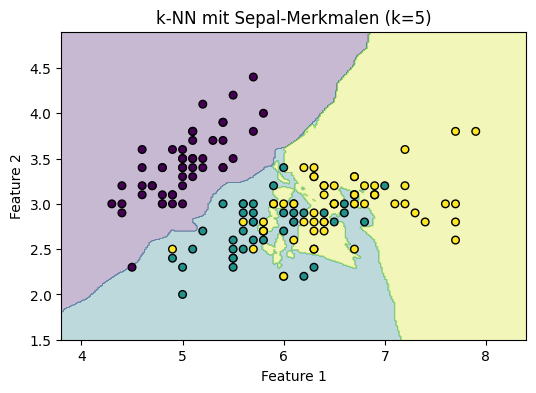

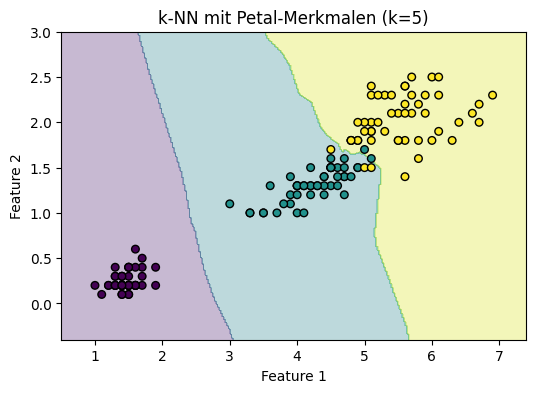

In [ ]:
def plot_decision_boundary_2d(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=30)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

knn_sepal = KNeighborsClassifier(n_neighbors=5)
knn_sepal.fit(X_sepal, y)
plot_decision_boundary_2d(knn_sepal, X_sepal, y, "k-NN mit Sepal-Merkmalen (k=5)")

knn_petal = KNeighborsClassifier(n_neighbors=5)
knn_petal.fit(X_petal, y)
plot_decision_boundary_2d(knn_petal, X_petal, y, "k-NN mit Petal-Merkmalen (k=5)")

## 7. Konfusionsmatrix für das 4-Merkmals-Modell

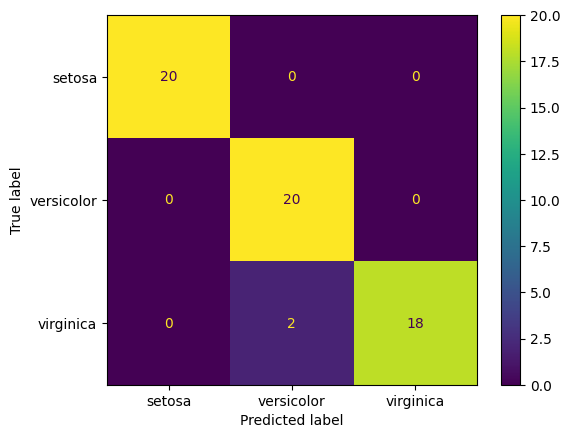

In [ ]:
cm = confusion_matrix(y_test, y_pred_4)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()
plt.show()

## 8. Längere Übungsaufgabe

1. Bestimmen Sie für **alle 4 Merkmale** den besten Wert von `k` aus der Menge  
   `{1, 3, 5, 7, 9, 11}`.

2. Wiederholen Sie den Vergleich für:
   - nur die beiden Sepal-Merkmale
   - nur die beiden Petal-Merkmale

3. Formulieren Sie eine kurze schriftliche Interpretation:
   - Welche Merkmalsgruppe funktioniert besser?
   - Warum könnte das so sein?

4. Vergleichen Sie zwei Modelle mit guter Accuracy:
   - eines mit 4 Merkmalen
   - eines mit 2 Merkmalen

   Diskutieren Sie:
   - Ist mehr Information immer besser?
   - Wann kann ein einfacherer Merkmalsraum sogar vorteilhaft sein?

## 9. Fazit

- k-NN kann bereits auf einem kleinen Datensatz sehr gute Ergebnisse liefern.
- Die Wahl von `k` hat spürbaren Einfluss auf die Modellgüte.
- Nicht alle Merkmale sind gleich informativ.
- Auf Iris sind die **Petal-Merkmale** oft besonders trennscharf.

## 10. Musterlösung zur längeren Übungsaufgabe

Im Folgenden wird die Übungsaufgabe vollständig gelöst.

**Ziel der Musterlösung**
- den besten Wert von `k` für verschiedene Merkmalsräume bestimmen
- Sepal- und Petal-Merkmale systematisch vergleichen
- die Ergebnisse fachlich interpretieren

Wichtig:
Die exakten Accuracy-Werte können je nach `scikit-learn`-Version leicht variieren.
Die **didaktisch stabile Kernaussage** bleibt aber typischerweise gleich:
- **Petal-Merkmale** funktionieren meist besser als **Sepal-Merkmale**
- alle 4 Merkmale liefern oft sehr gute Ergebnisse
- mehr Information ist hilfreich, aber nicht automatisch immer deutlich besser

In [ ]:
# Musterlösung Teil 1:
# Bestes k für alle 4 Merkmale bestimmen

df_4_sorted = df_4.sort_values(["Accuracy", "k"], ascending=[False, True]).reset_index(drop=True)
df_4_sorted

,k,Accuracy
0,3,0.9667
1,7,0.9667
2,9,0.9667
3,1,0.9500
4,11,0.9500
5,5,0.9333


In [ ]:
best_k_4 = df_4_sorted.loc[0, "k"]
best_acc_4 = df_4_sorted.loc[0, "Accuracy"]

print("Bestes k mit 4 Merkmalen:", best_k_4)
print("Beste Accuracy mit 4 Merkmalen:", best_acc_4)

Bestes k mit 4 Merkmalen: 3
Beste Accuracy mit 4 Merkmalen: 0.9667


In [ ]:
# Musterlösung Teil 2:
# Bestes k für Sepal- und Petal-Merkmale bestimmen

best_by_variant = (
    df_compare.sort_values(["Variante", "Accuracy", "k"], ascending=[True, False, True])
    .groupby("Variante", as_index=False)
    .first()
)

best_by_variant

,Variante,k,Accuracy
0,Petal (2 Merkmale),1,0.9833
1,Sepal (2 Merkmale),5,0.8333


### Interpretation der Ergebnisse

Typischerweise zeigt sich:

- Die **Petal-Merkmale** liefern deutlich bessere Accuracy-Werte als die **Sepal-Merkmale**.
- Das Modell mit **allen 4 Merkmalen** ist oft sehr gut, aber der Zugewinn gegenüber den Petal-Merkmalen allein ist manchmal nur noch moderat.
- Die **Sepal-Merkmale** trennen die Iris-Klassen meist deutlich schlechter.

**Didaktische Deutung:**  
k-NN arbeitet direkt im Merkmalsraum. Deshalb ist entscheidend, wie gut die Klassen geometrisch getrennt sind.

In [ ]:
# Musterlösung Teil 3:
# Ergebnisse in einer kompakten Vergleichstabelle zusammenfassen

summary_rows = [
    {
        "Variante": "Alle 4 Merkmale",
        "Bestes k": int(best_k_4),
        "Beste Accuracy": float(best_acc_4)
    }
]

for _, row in best_by_variant.iterrows():
    summary_rows.append({
        "Variante": row["Variante"],
        "Bestes k": int(row["k"]),
        "Beste Accuracy": float(row["Accuracy"])
    })

summary_df = pd.DataFrame(summary_rows).round(4)
summary_df

,Variante,Bestes k,Beste Accuracy
0,Alle 4 Merkmale,3,0.9667
1,Petal (2 Merkmale),1,0.9833
2,Sepal (2 Merkmale),5,0.8333


### Musterantwort auf die Reflexionsfragen

**1. Welche Merkmalsgruppe funktioniert besser?**  
In der Regel funktionieren die **Petal-Merkmale** besser.

**2. Warum könnte das so sein?**  
Weil die Klassen im Iris-Datensatz über Petal-Länge und Petal-Breite meist klarer getrennt sind.  
Dadurch liegen Punkte derselben Klasse im Merkmalsraum näher beieinander.

**3. Ist mehr Information immer besser?**  
Nicht unbedingt. Zusätzliche Merkmale helfen nur dann, wenn sie tatsächlich relevante Information beitragen.  
Irrelevante oder schwächere Merkmale können im Prinzip sogar stören.

**4. Wann kann ein einfacherer Merkmalsraum vorteilhaft sein?**  
Wenn wenige Merkmale die Klassen bereits sehr gut trennen, ist ein kleinerer Merkmalsraum oft leichter zu visualisieren, leichter zu interpretieren und manchmal nahezu genauso leistungsfähig.

## 11. Didaktische Hinweise für die Vorlesung

Dieses Notebook eignet sich gut, um drei Punkte zu betonen:

1. **k-NN ist geometrisch gedacht.**  
   Das Verfahren lernt keine globale Formel, sondern nutzt Nachbarschaft im Merkmalsraum.

2. **Merkmalswahl ist zentral.**  
   Nicht alle Features sind gleich hilfreich.

3. **Mehr Merkmale bedeuten nicht automatisch einen großen Zusatznutzen.**  
   Manchmal leisten zwei gute Merkmale fast so viel wie vier Merkmale zusammen.

Für die Besprechung im Unterricht ist besonders wertvoll:
- Vergleich **Sepal vs. Petal**
- Zusammenhang zwischen **Trennbarkeit** und **Modellgüte**
- Übergang zur Frage, warum Distanzverfahren in hohen Dimensionen schwieriger werden